In [2]:
import sys
sys.path.append("../")
import numpy as np
from dotenv import load_dotenv
import os
import matplotlib.pyplot as plt

#load the necessary odometry modules
from cpsl_datasets.cpsl_ds import CpslDS
from cpsl_datasets.map_handler import MapHandler
from odometry.localization.icp2D_localization import icp2DLocalization
from  odometry.supportFns import rotation_functions

#point cloud field of view test bench
from odometry.test_benches.lidar_icp_localization_tb import lidarICPLocalization

In [3]:
#loading enviroment variables
load_dotenv()
DATASET_PATH= os.getenv("DATASET_DIRECTORY")
MAP_DIRECTORY= os.getenv("MAP_DIRECTORY")

#setup the datasets
folder_name = "WILK"
file_name = "WILK_Multipath_Test_1"
#folder_name = "WILK_BASEMENT"
#file_name = "wilk_basement_1"

dataset = CpslDS(
    dataset_path=os.path.join(DATASET_PATH,folder_name,file_name), #_spin_recall
    radar_folder="radar_combined",
    lidar_folder="lidar",
    camera_folder="camera",
    imu_orientation_folder="imu_data",
    imu_full_folder="imu_data_full",
    vehicle_vel_folder="vehicle_vel"
)


#available maps: "wilkinson.yaml","wilk_basement.yaml"
map_handler = MapHandler(
    maps_folder=MAP_DIRECTORY,
    map_file="wilkinson.yaml"
)

found 1184 radar samples
found 1184 lidar samples
found 1184 camera samples
found 1184 imu (orientation only) samples
found 1184imu (full data) samples
found 1184 vehicle velocity samples
loaded map from /data/radnav/maps/wilkinson.yaml
loaded map free space from /data/radnav/maps/wilkinson.yaml


In [4]:
#initialize a ground truth localizer
lidar_odometry = icp2DLocalization(
    icp_matching_distance_threshold=0.6, #originally 0.6
    icp_best_points_percentile=50,
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=10,
    icp_max_iterations=20,
    self_detection_radius_m=0.25
)

loaded map with 20750 points
icp estimated heading:1.342238612043568 deg, pose:[-0.02763011  0.21487372]


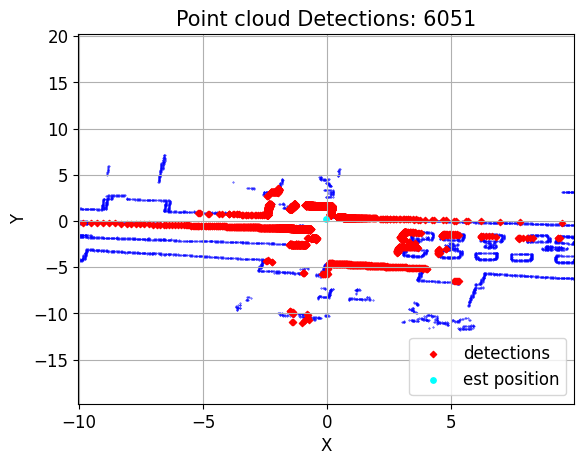

In [5]:
#initialize the test bench
test_bench = lidarICPLocalization(
    gt_localizer=lidar_odometry,
    map_handler=map_handler,
    dataset=dataset
)

start_heading = np.deg2rad(0)
start_pose = np.array([0.03,0.11])

#initialize the localization
test_bench.init_localization(
    est_start_heading_rad=start_heading,
    est_start_pose_m=start_pose,
    show=True
)

In [6]:
#compute the ground truth for each frame in the dataset
test_bench.run()

100%|██████████| 1184/1184 [01:43<00:00, 11.49it/s]


## Overview of generated plots

### Ground truth location over the test set

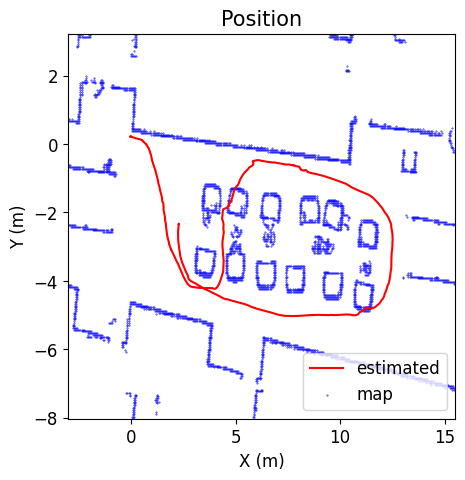

In [7]:
fig, axs = plt.subplots(figsize=(5,5))

test_bench.plotter.plot_position_history_m(
    history_position_m=test_bench.history_position_m_gt,
    idx=dataset.num_frames-1,
    ax=axs,
    show=True
)

### Lidar point cloud at any given frame

position: [ 4.90500429 -4.58412878],heading: -188.57057388820166 deg


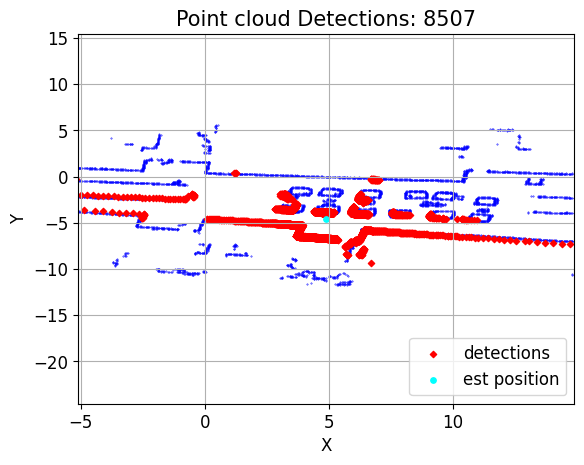

In [8]:
frame_idx = 1000

#get the pose and heading for the given frame
pose_m = test_bench.history_position_m_gt[frame_idx]
heading_deg = test_bench.history_heading_deg_gt[frame_idx]
print("position: {},heading: {} deg".format(pose_m,heading_deg))

#get the lidar points (a 2D slice at the vehicle's height) at the given frame
lidar_pc = dataset.get_lidar_point_cloud(idx=frame_idx)

test_bench.plotter.plot_detections_on_map(
    current_points = lidar_pc,
    heading_rad = np.deg2rad(heading_deg),
    pose_m=pose_m,
    show=True
)

### Other helpful accessing

In [9]:
frame_idx = 1000

# accessing the full 3d point cloud
lidar_pc_3d = dataset.get_lidar_point_cloud_raw(idx=frame_idx)

#rotating/translating a 2d lidar point cloud from the agent frame 
# to the map frame
lidar_pc_2d = dataset.get_lidar_point_cloud(idx=frame_idx)
aligned_points = rotation_functions.apply_rot_trans(
    points=lidar_pc_2d,
    rot_angle_rad=np.deg2rad(heading_deg),
    trans=pose_m
)

In [12]:
frame_idx = 1000

imu_data_raw = dataset.get_imu_full_data(idx=frame_idx)
print(imu_data_raw.shape)


(10, 7)
